
0: 480x640 6 As, 3 Cs, 3 Ds, 3 Es, 2 Hs, 2 Is, 1 K, 4 Ls, 1 N, 2 Os, 1 P, 2 Rs, 2 Ss, 6 Ts, 2 Us, 1 V, 1 W, 3 Ys, 91.9ms
Speed: 3.7ms preprocess, 91.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


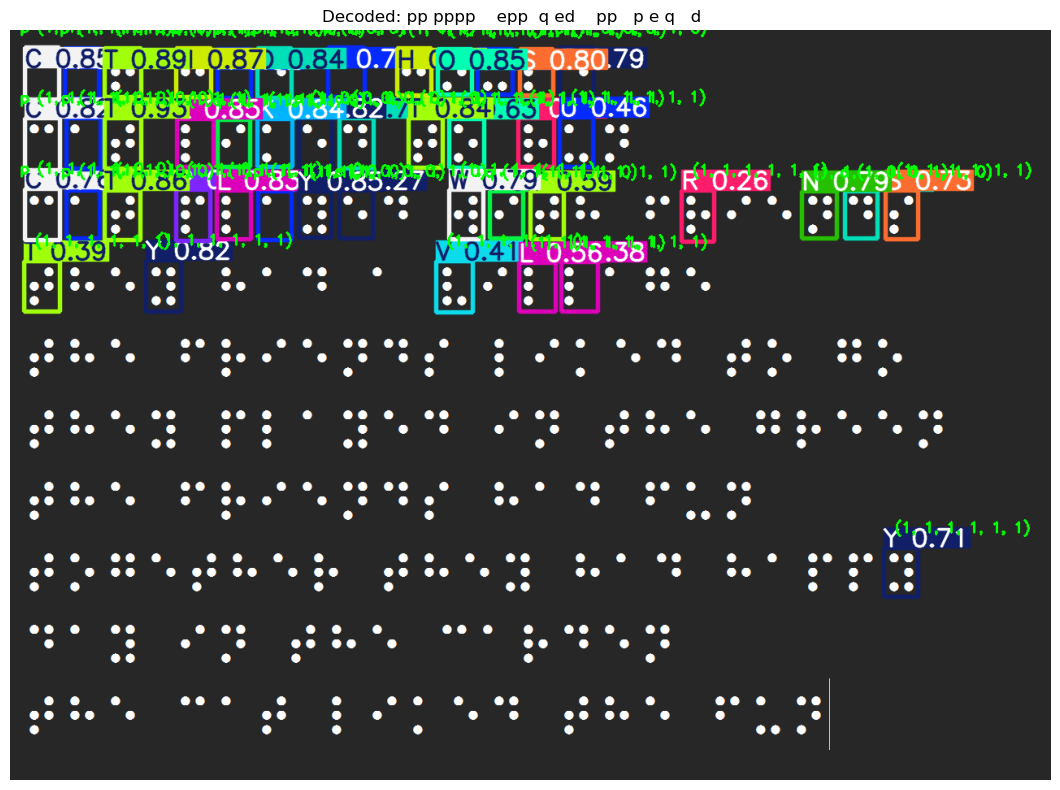


DECODED SENTENCE: pp pppp    epp  q ed    pp   p e q   d       

Validation results (predicted_filename -> decoded, grid):
C-001.png (C) -> p	(1, 1, 1, 1, 0, 0)
A-001.png (A) -> p	(1, 1, 1, 1, 0, 0)
T-001.png (T) ->  	(1, 1, 1, 1, 1, 1)
H-001.png (H) -> p	(1, 1, 1, 1, 0, 0)
A-002.png (A) -> p	(1, 1, 1, 1, 0, 0)
D-001.png (D) -> p	(1, 1, 1, 1, 0, 0)
A-003.png (A) -> p	(1, 1, 1, 1, 0, 0)
H-002.png (H) ->  	(1, 1, 1, 1, 1, 1)
O-001.png (O) ->  	(1, 1, 1, 1, 1, 1)
U-001.png (U) ->  	(1, 1, 1, 1, 1, 1)
S-001.png (S) ->  	(1, 1, 1, 1, 1, 1)
E-001.png (E) -> e	(1, 0, 0, 0, 1, 0)
C-002.png (C) -> p	(1, 1, 1, 1, 0, 0)
A-004.png (A) -> p	(1, 1, 1, 1, 0, 0)
T-002.png (T) ->  	(1, 1, 1, 1, 1, 1)
L-001.png (L) ->  	(1, 1, 1, 1, 1, 1)
I-001.png (I) -> q	(1, 1, 1, 1, 1, 0)
K-001.png (K) ->  	(1, 1, 1, 1, 1, 1)
E-002.png (E) -> e	(1, 0, 0, 0, 1, 0)
D-002.png (D) -> d	(1, 0, 0, 1, 1, 0)
T-003.png (T) ->  	(1, 1, 1, 1, 1, 1)
O-002.png (O) ->  	(1, 1, 1, 1, 1, 1)
R-001.png (R) ->  	(1, 1, 1, 1, 1, 1)
U-

In [4]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import DBSCAN
import csv
import os
from datetime import datetime
import re

# --- Braille mapping: tuple order is (dot1, dot2, dot3, dot4, dot5, dot6) ---
BRAILLE_TO_ENGLISH = {
    (1, 0, 0, 0, 0, 0): 'a', (1, 1, 0, 0, 0, 0): 'b', (1, 0, 0, 1, 0, 0): 'c',
    (1, 0, 0, 1, 1, 0): 'd', (1, 0, 0, 0, 1, 0): 'e', (1, 1, 0, 1, 0, 0): 'f',
    (1, 1, 0, 1, 1, 0): 'g', (1, 1, 0, 0, 1, 0): 'h', (0, 1, 0, 1, 0, 0): 'i',
    (0, 1, 0, 1, 1, 0): 'j', (1, 0, 1, 0, 0, 0): 'k', (1, 1, 1, 0, 0, 0): 'l',
    (1, 0, 1, 1, 0, 0): 'm', (1, 0, 1, 1, 1, 0): 'n', (1, 0, 1, 0, 1, 0): 'o',
    (1, 1, 1, 1, 0, 0): 'p', (1, 1, 1, 1, 1, 0): 'q', (1, 1, 1, 0, 1, 0): 'r',
    (0, 1, 1, 1, 0, 0): 's', (0, 1, 1, 1, 1, 0): 't', (1, 0, 1, 0, 0, 1): 'u',
    (1, 1, 1, 0, 0, 1): 'v', (0, 1, 0, 1, 1, 1): 'w', (1, 0, 1, 1, 0, 1): 'x',
    (1, 0, 1, 1, 1, 1): 'y', (1, 0, 1, 0, 1, 1): 'z', (0, 0, 0, 0, 0, 0): ' ',
    (0, 1, 0, 0, 1, 1): '.', (0, 1, 1, 0, 0, 1): ',', (0, 1, 1, 0, 1, 1): '?',
    (1, 0, 0, 0, 0, 1): "'", (0, 0, 1, 0, 1, 1): '!', (0, 1, 0, 0, 0, 1): '-',
    (0, 0, 1, 1, 1, 0): ';', (0, 0, 1, 1, 0, 1): ':', (1, 1, 0, 0, 0, 1): '1',
    (1, 1, 0, 0, 1, 1): '2', (1, 0, 0, 1, 0, 1): '3', (1, 0, 0, 1, 1, 1): '4',
    (1, 0, 0, 0, 1, 1): '5', (1, 1, 0, 1, 0, 1): '6', (1, 1, 0, 1, 1, 1): '7',
    (1, 1, 0, 0, 1, 1): '8', (0, 1, 0, 1, 0, 1): '9', (0, 1, 0, 1, 1, 1): '0'
}

# ---------------- Utility functions ----------------

def sanitize_filename(char):
    if not char or str(char).isspace():
        return "space"
    if char == "?":
        return "unknown"
    safe = re.sub(r'[^A-Za-z0-9]', '', str(char))
    if safe == "":
        safe = "unknown"
    return safe

def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    denoised = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 5)
    return thresh

def detect_dots(image):
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 5
    params.maxArea = 500
    params.filterByCircularity = True
    params.minCircularity = 0.4
    params.filterByConvexity = True
    params.minConvexity = 0.7
    params.filterByInertia = True
    params.minInertiaRatio = 0.3
    detector = cv2.SimpleBlobDetector_create(params)
    return detector.detect(image)

# ------------- IMPORTANT: consistent grid ordering (col-major) -------------
# We'll use index order: [dot1, dot2, dot3, dot4, dot5, dot6]
# i.e. left column top->bottom (1,2,3), then right column top->bottom (4,5,6).

def grid_from_rpn_bbox(char_img, keypoints):
    h, w = char_img.shape[:2]
    grid = np.zeros(6, dtype=int)
    if len(keypoints) == 0:
        return tuple(grid)
    cell_w = w / 2.0   # 2 columns
    cell_h = h / 3.0   # 3 rows
    for kp in keypoints:
        x, y = kp.pt
        col = min(1, max(0, int(x / cell_w)))   # 0 or 1
        row = min(2, max(0, int(y / cell_h)))   # 0,1,2
        pos = col * 3 + row   # col-major mapping -> 0..5
        grid[pos] = 1
    return tuple(grid)

def fit_2x3_grid(keypoints, img_shape):
    # same col-major ordering (1..6) as above
    grid = np.zeros(6, dtype=int)
    h, w = img_shape
    if len(keypoints) == 0:
        return tuple(grid)
    cell_width = w / 2.0
    cell_height = h / 3.0
    for kp in keypoints:
        x, y = kp.pt
        col = min(1, max(0, int(x / cell_width)))
        row = min(2, max(0, int(y / cell_height)))
        pos = col * 3 + row
        grid[pos] = 1
    return tuple(grid)

def dbscan_fallback(keypoints, img_shape):
    if len(keypoints) == 0:
        return (0,0,0,0,0,0)
    points = np.array([kp.pt for kp in keypoints])
    clustering = DBSCAN(eps=15, min_samples=1).fit(points)
    labels = clustering.labels_
    grid = np.zeros(6, dtype=int)
    h, w = img_shape[:2]
    for lab in set(labels):
        pts = points[labels == lab]
        if len(pts) == 0:
            continue
        center = np.mean(pts, axis=0)
        # 2 columns (width/2), 3 rows (height/3)
        col = min(1, max(0, int(center[0] / (w / 2.0))))
        row = min(2, max(0, int(center[1] / (h / 3.0))))
        pos = col * 3 + row
        if pos < 6:
            grid[pos] = 1
    return tuple(grid)

def decode_braille(grid):
    # grid must be tuple in (1..6) order
    char = BRAILLE_TO_ENGLISH.get(tuple(grid), '?')
    if char == '?':
        inverted = tuple(1 - int(x) for x in grid)
        char = BRAILLE_TO_ENGLISH.get(inverted, '?')
    return char

def draw_grid_on_image(image, grid_pattern):
    # Positions must match our tuple order: [dot1,dot2,dot3,dot4,dot5,dot6]
    h, w = image.shape[:2]
    grid_img = image.copy()
    # vertical middle line (col separator)
    cv2.line(grid_img, (w//2, 0), (w//2, h), (0, 255, 0), 1)
    # horizontal separators for 3 rows
    for r in range(1, 3):
        cv2.line(grid_img, (0, r*h//3), (w, r*h//3), (0, 255, 0), 1)

    # dot positions in col-major order (left-top, left-mid, left-bottom, right-top, ...)
    positions = [
        (int(w*0.25), int(h*0.166)),  # dot1 (left top)
        (int(w*0.25), int(h*0.5)),    # dot2 (left middle)
        (int(w*0.25), int(h*0.833)),  # dot3 (left bottom)
        (int(w*0.75), int(h*0.166)),  # dot4 (right top)
        (int(w*0.75), int(h*0.5)),    # dot5 (right middle)
        (int(w*0.75), int(h*0.833))   # dot6 (right bottom)
    ]

    dot_radius = max(2, min(w, h)//15)
    for i, has_dot in enumerate(grid_pattern):
        if has_dot:
            cv2.circle(grid_img, positions[i], dot_radius, (0, 0, 255), -1)
    return grid_img

# ---------------- Row clustering but for items (box + meta) ----------------
def cluster_row_items(items, height_threshold=0.7):
    """
    items: list of tuples (box, meta...) where box is [x1,y1,x2,y2]
    returns: list of rows (each a list of items), rows sorted vertically and items in row sorted by x
    """
    if len(items) == 0:
        return []
    boxes = [it[0] for it in items]
    avg_h = np.mean([box[3] - box[1] for box in boxes])
    thresh = avg_h * height_threshold
    # sort by y1
    items_sorted = sorted(items, key=lambda it: it[0][1])
    rows = []
    cur_row = [items_sorted[0]]
    for it in items_sorted[1:]:
        y_center = (it[0][1] + it[0][3]) / 2.0
        prev_y_center = (cur_row[-1][0][1] + cur_row[-1][0][3]) / 2.0
        if y_center - prev_y_center < thresh:
            cur_row.append(it)
        else:
            # sort current row by x (left->right)
            rows.append(sorted(cur_row, key=lambda it2: it2[0][0]))
            cur_row = [it]
    rows.append(sorted(cur_row, key=lambda it2: it2[0][0]))
    return rows

# ---------------- Save extracted images named by YOLO predicted label ----------------
def save_detected_characters_by_prediction(image, items, output_dir="detected_characters"):
    """
    items: list of tuples (box, pred_label, orig_index)
    Save char images named with predicted label.
    Returns list of dicts with metadata for each saved file.
    """
    os.makedirs(output_dir, exist_ok=True)
    char_count = defaultdict(int)
    saved_infos = []
    for i, (box, pred_label, orig_idx) in enumerate(items):
        x1, y1, x2, y2 = map(int, box)
        w, h = x2 - x1, y2 - y1
        # expand box a bit
        padx, pady = int(0.15*w), int(0.15*h)
        x1n = max(0, x1 - padx); y1n = max(0, y1 - pady)
        x2n = min(image.shape[1], x2 + padx); y2n = min(image.shape[0], y2 + pady)
        char_img = image[y1n:y2n, x1n:x2n]
        if char_img.size == 0:
            continue
        safe_pred = sanitize_filename(pred_label)
        char_count[safe_pred] += 1
        count = char_count[safe_pred]
        filename = f"{safe_pred}-{count:03d}.png"
        save_path = os.path.join(output_dir, filename)
        cv2.imwrite(save_path, char_img)
        saved_infos.append({
            "path": save_path,
            "pred_label": pred_label,
            "saved_name": filename,
            "box": (x1n, y1n, x2n, y2n),
            "orig_index": orig_idx
        })
    return saved_infos

# ---------------- Validate detected characters & create overlays ----------------
def validate_detected_characters_from_infos(char_infos, output_dir="detected_characters"):
    """
    char_infos: list of dicts returned by save_detected_characters_by_prediction
    Will not overwrite the original predicted-named image; instead it:
      - writes a grid overlay named <predicted_base>_grid.png in output_dir/with_grid
      - creates a mapping CSV predicted_vs_decoded.csv
      - saves decoded copies in output_dir/decoded_by_braille (optional)
    Returns a list of dicts: {predicted_filename, decoded_char, grid_pattern}
    """
    grid_output_dir = os.path.join(output_dir, "with_grid")
    decoded_dir = os.path.join(output_dir, "decoded_by_braille")
    debug_dir = os.path.join(output_dir, "debug_threshold")
    
    os.makedirs(grid_output_dir, exist_ok=True)
    os.makedirs(decoded_dir, exist_ok=True)
    os.makedirs(debug_dir, exist_ok=True)

    results_map = []
    decoded_count = defaultdict(int)

    for info in char_infos:
        char_img = cv2.imread(info["path"])
        if char_img is None:
            results_map.append({
                "predicted": info["saved_name"],
                "decoded": "ERROR",
                "grid": (0,0,0,0,0,0)
            })
            continue

        # Save debug images
        base_name = os.path.splitext(info["saved_name"])[0]
        debug_path = os.path.join(debug_dir, f"{base_name}_threshold.png")
        
        # Create debug image showing different thresholding approaches
        gray = cv2.cvtColor(char_img, cv2.COLOR_BGR2GRAY)
        avg_intensity = np.mean(gray)
        
        # Apply different thresholding methods
        th1 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 21, 10)
        th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 10)
        
        # Apply Otsu's thresholding
        _, th3 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        _, th4 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        # Create a debug image with all thresholding results
        debug_img_top = np.hstack([gray, th1, th2])
        debug_img_bottom = np.hstack([th3, th4, np.zeros_like(gray)])
        debug_img = np.vstack([debug_img_top, debug_img_bottom])
        
        # Add text showing the average intensity
        cv2.putText(debug_img, f"Avg: {avg_intensity:.1f}", (10, 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Original", (10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Binary", (gray.shape[1] + 10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Binary Inv", (2*gray.shape[1] + 10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Otsu", (10, 2*gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Otsu Inv", (gray.shape[1] + 10, 2*gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        cv2.imwrite(debug_path, debug_img)

        # Try pixel-density method first (more robust for small YOLO crops)
        grid = detect_braille_grid(char_img)
        decoded = decode_braille(grid)

        # Fallback 1: blob-based
        if decoded == '?':
            processed = preprocess_image(char_img)
            keypoints = detect_dots(processed)
            grid = grid_from_rpn_bbox(char_img, keypoints)
            decoded = decode_braille(grid)

        # Fallback 2: DBSCAN
        if decoded == '?':
            grid = dbscan_fallback(keypoints, char_img.shape)
            decoded = decode_braille(grid)
            
        # Save overlay using predicted base name (so you can immediately relate)
        grid_img = draw_grid_on_image(char_img, grid)
        grid_path = os.path.join(grid_output_dir, f"{base_name}_grid.png")
        cv2.imwrite(grid_path, grid_img)

        # Also save a decoded-named copy (optional, handy for inspection)
        safe_dec = sanitize_filename(decoded)
        decoded_count[safe_dec] += 1
        dec_filename = f"{safe_dec}-{decoded_count[safe_dec]:03d}.png"
        dec_path = os.path.join(decoded_dir, dec_filename)
        cv2.imwrite(dec_path, char_img)

        results_map.append({
            "predicted": info["saved_name"],
            "predicted_label": info["pred_label"],
            "decoded": decoded,
            "grid": tuple(grid),
            "grid_overlay_predicted": os.path.relpath(grid_path, output_dir),
            "decoded_copy": os.path.relpath(dec_path, output_dir),
            "threshold_debug": os.path.relpath(debug_path, output_dir)
        })

    # Save mapping CSV
    csv_path = os.path.join(output_dir, "predicted_vs_decoded.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["predicted_filename", "predicted_label", "decoded_char", "grid_pattern", 
                         "grid_overlay", "decoded_copy", "threshold_debug"])
        for r in results_map:
            writer.writerow([
                r["predicted"], r.get("predicted_label",""), r["decoded"], ''.join(map(str, r["grid"])),
                r["grid_overlay_predicted"], r["decoded_copy"], r["threshold_debug"]
            ])
    return results_map

def log_metrics(image_path, total_chars, successful, failed):
    os.makedirs('logs', exist_ok=True)
    log_path = f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv"
    file_exists = os.path.exists(log_path)
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Image', 'Total', 'Decoded', 'Failed', 'Success Rate'])
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        success_rate = successful/total_chars if total_chars>0 else 0
        writer.writerow([timestamp, os.path.basename(image_path), total_chars, successful, failed, f"{success_rate:.2%}"])

# ---------------- Main pipeline ----------------
def process_braille_image(model, image_path=None, camera_snapshot=False):
    # Load image
    if camera_snapshot:
        cap = cv2.VideoCapture(0)
        ret, img = cap.read()
        cap.release()
        if not ret:
            print("Error capturing image")
            return
    else:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Image not found: {image_path}")
            return

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = f"detected_characters_{timestamp}"
    os.makedirs(output_dir, exist_ok=True)

    # Run YOLO detection
    results = model(img)   # ultralytics result
    r = results[0]

    # boxes and class indices
    boxes = r.boxes.xyxy.cpu().numpy() if hasattr(r.boxes, 'xyxy') else np.array([])
    # attempt to extract classes (works with typical ultralytics)
    try:
        cls_arr = r.boxes.cls.cpu().numpy().astype(int)
    except Exception:
        # fallback: if cls not available, put unknown labels
        cls_arr = np.array([-1]*len(boxes), dtype=int)

    # map class idx -> class name if available (r.names is dict)
    names_map = getattr(r, "names", {}) or {}
    pred_labels = [ names_map[int(c)] if int(c) in names_map else str(int(c)) for c in cls_arr ]

    # pair each box with its predicted label and original index
    items = []
    for idx, (box, pl) in enumerate(zip(boxes, pred_labels)):
        items.append((box.tolist(), pl, idx))

    # Cluster into rows and sort left->right inside each row
    rows = cluster_row_items(items)
    sorted_items = [it for row in rows for it in row]  # flatten

    # Save extracted char images named by YOLO predicted label
    char_infos = save_detected_characters_by_prediction(img, sorted_items, output_dir)

    # Validate each character (create overlays + decoded copies + mapping CSV)
    validation_results = validate_detected_characters_from_infos(char_infos, output_dir)

    # Create annotated image (use YOLO's plot but annotate with decoded)
    annotated_img = r.plot() if hasattr(r, "plot") else img.copy()

    decoded_chars = []
    successful = 0
    for i, (info, val) in enumerate(zip(char_infos, validation_results)):
        # We have info["box"] in image coordinates; draw label at box top-left
        x1, y1, x2, y2 = info["box"]
        decoded = val["decoded"]
        grid = val["grid"]
        color = (0,255,0) if decoded != '?' else (0,0,255)
        cv2.putText(annotated_img, f"{decoded} {grid}", (int(x1), int(y1)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        decoded_chars.append(decoded)
        if decoded != '?':
            successful += 1

    sentence = ''.join(decoded_chars)
    total_chars = len(sorted_items)

    # Save annotated image and show
    annotated_path = os.path.join(output_dir, "annotated_result.png")
    cv2.imwrite(annotated_path, annotated_img)
    plt.figure(figsize=(15,8))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Decoded: {sentence}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "result_plot.png"))
    plt.show()

    # Print summary
    print("\n" + "="*50)
    print(f"DECODED SENTENCE: {sentence}")
    print("="*50)
    print("\nValidation results (predicted_filename -> decoded, grid):")
    for r in validation_results:
        print(f"{r['predicted']} ({r.get('predicted_label','')}) -> {r['decoded']}\t{r['grid']}")

    failed = total_chars - successful
    if not camera_snapshot:
        log_metrics(image_path, total_chars, successful, failed)

    print(f"\nDebugging files saved to: {output_dir}")
    print(f"Mapping CSV: {os.path.join(output_dir, 'predicted_vs_decoded.csv')}")

def debug_braille_detection(char_img, output_path):
    """Save debug images showing the braille detection process."""
    gray = cv2.cvtColor(char_img, cv2.COLOR_BGR2GRAY)
    avg_intensity = np.mean(gray)
    
    # Apply both thresholding methods
    th1 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY, 21, 10)
    th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 21, 10)
    
    # Create a debug image with both thresholding results
    debug_img = np.hstack([gray, th1, th2])
    
    # Add text showing the average intensity
    cv2.putText(debug_img, f"Avg: {avg_intensity:.1f}", (10, 20), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    cv2.imwrite(output_path, debug_img)

def detect_braille_grid(img):
    """Detect 2x3 braille grid from character image using pixel density."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Adaptive threshold (good for uneven lighting)
    th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 21, 10)
    
    # Clean up: opening (remove small noise) then closing (solidify dots)
    kernel = np.ones((3,3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
    
    h, w = th.shape
    cell_h, cell_w = h // 3, w // 2
    grid = []
    
    for row in range(3):
        for col in range(2):
            cell = th[row*cell_h:(row+1)*cell_h, col*cell_w:(col+1)*cell_w]
            dot_pixels = cv2.countNonZero(cell)
            ratio = dot_pixels / float(cell.size)
            # much lower threshold: even 1% dot pixels is enough
            grid.append(1 if ratio > 0.01 else 0)
    
    return tuple(grid)


# ---------------- run ----------------
if __name__ == "__main__":
    # Load trained model - adjust path for your environment
    model = YOLO(r"D:\Papers\Braille\braille_char\v8n\weights\best.pt")
    use_camera = False
    image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\Screenshot 2025-09-05 160624.png"
    process_braille_image(model, image_path, camera_snapshot=use_camera)

**ORIGINAL CODE**

In [64]:
import os
import re
import csv
import cv2
import numpy as np
from datetime import datetime
from collections import defaultdict
from ultralytics import YOLO
import pyttsx3
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# ===================== BRAILLE MAPPING =====================
BRAILLE_TO_ENGLISH = {
    (1, 0, 0, 0, 0, 0): 'a', (1, 1, 0, 0, 0, 0): 'b', (1, 0, 0, 1, 0, 0): 'c',
    (1, 0, 0, 1, 1, 0): 'd', (1, 0, 0, 0, 1, 0): 'e', (1, 1, 0, 1, 0, 0): 'f',
    (1, 1, 0, 1, 1, 0): 'g', (1, 1, 0, 0, 1, 0): 'h', (0, 1, 0, 1, 0, 0): 'i',
    (0, 1, 0, 1, 1, 0): 'j', (1, 0, 1, 0, 0, 0): 'k', (1, 1, 1, 0, 0, 0): 'l',
    (1, 0, 1, 1, 0, 0): 'm', (1, 0, 1, 1, 1, 0): 'n', (1, 0, 1, 0, 1, 0): 'o',
    (1, 1, 1, 1, 0, 0): 'p', (1, 1, 1, 1, 1, 0): 'q', (1, 1, 1, 0, 1, 0): 'r',
    (0, 1, 1, 1, 0, 0): 's', (0, 1, 1, 1, 1, 0): 't', (1, 0, 1, 0, 0, 1): 'u',
    (1, 1, 1, 0, 0, 1): 'v', (0, 1, 0, 1, 1, 1): 'w', (1, 0, 1, 1, 0, 1): 'x',
    (1, 0, 1, 1, 1, 1): 'y', (1, 0, 1, 0, 1, 1): 'z', (0, 0, 0, 0, 0, 0): ' ',
    (0, 1, 0, 0, 1, 1): '.', (0, 1, 1, 0, 0, 1): ',', (0, 1, 1, 0, 1, 1): '?',
    (1, 0, 0, 0, 0, 1): "'", (0, 0, 1, 0, 1, 1): '!', (0, 1, 0, 0, 0, 1): '-',
    (0, 0, 1, 1, 1, 0): ';', (0, 0, 1, 1, 0, 1): ':', (1, 1, 0, 0, 0, 1): '1',
    (1, 1, 0, 0, 1, 1): '2', (1, 0, 0, 1, 0, 1): '3', (1, 0, 0, 1, 1, 1): '4',
    (1, 0, 0, 0, 1, 1): '5', (1, 1, 0, 1, 0, 1): '6', (1, 1, 0, 1, 1, 1): '7',
    (1, 1, 0, 0, 1, 1): '8', (0, 1, 0, 1, 0, 1): '9', (0, 1, 0, 1, 1, 1): '0'
}

def calculate_grid_confidence(crop_img, grid_pattern):
    """Calculate confidence score for grid detection based on dot clarity and pattern."""
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    
    # Calculate contrast score
    contrast = np.std(gray)
    contrast_score = min(1.0, contrast / 50.0)  # Normalize contrast score
    
    # Calculate dot clarity score
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    dot_clarity = 0
    if contours:
        areas = [cv2.contourArea(cnt) for cnt in contours]
        dot_clarity = np.mean(areas) / 100.0  # Normalize area score
        dot_clarity = min(1.0, dot_clarity)
    
    # Pattern validity score (1.0 if pattern exists in mapping, 0.5 if inverted exists, 0.2 otherwise)
    pattern_score = 1.0 if tuple(grid_pattern) in BRAILLE_TO_ENGLISH else (
        0.5 if tuple(1 - x for x in grid_pattern) in BRAILLE_TO_ENGLISH else 0.2
    )
    
    # Combined confidence score
    confidence = 0.4 * contrast_score + 0.3 * dot_clarity + 0.3 * pattern_score
    return confidence
# ===================== IMPROVED GRID DETECTION =====================
def enhanced_preprocess_image(image):
    """Enhanced preprocessing for braille images."""
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply contrast-limited adaptive histogram equalization
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Apply bilateral filter to reduce noise while preserving edges
    filtered = cv2.bilateralFilter(enhanced, 9, 75, 75)
    
    return filtered

def optimized_detect_dots(image):
    """Optimized dot detection with better parameters."""
    params = cv2.SimpleBlobDetector_Params()
    
    # Filter by Area
    params.filterByArea = True
    params.minArea = 8  # Increased from 5
    params.maxArea = 200  # Reduced from 500
    
    # Filter by Circularity
    params.filterByCircularity = True
    params.minCircularity = 0.5  # Increased from 0.4
    
    # Filter by Convexity
    params.filterByConvexity = True
    params.minConvexity = 0.8  # Increased from 0.7
    
    # Filter by Inertia
    params.filterByInertia = True
    params.minInertiaRatio = 0.5  # Increased from 0.3
    
    # Create detector with updated parameters
    detector = cv2.SimpleBlobDetector_create(params)
    return detector.detect(image)

def robust_detect_braille_grid(img):
    """More robust braille grid detection with multiple validation checks."""
    # Enhanced preprocessing
    processed = enhanced_preprocess_image(img)
    
    # Try multiple thresholding methods
    methods = [
        lambda: cv2.adaptiveThreshold(processed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY_INV, 21, 5),
        lambda: cv2.adaptiveThreshold(processed, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                     cv2.THRESH_BINARY_INV, 21, 5),
        lambda: cv2.threshold(processed, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    ]
    
    best_grid = None
    best_score = -1
    
    for method in methods:
        try:
            th = method()
            
            # Clean up with morphological operations
            kernel = np.ones((3, 3), np.uint8)
            th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)
            th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
            
            h, w = th.shape
            cell_h, cell_w = h // 3, w // 2
            grid = []
            
            # Calculate grid with dynamic threshold
            overall_dot_ratio = cv2.countNonZero(th) / float(th.size)
            dynamic_threshold = max(0.08, min(0.25, overall_dot_ratio * 1.5))
            
            for row in range(3):
                for col in range(2):
                    cell = th[row*cell_h:(row+1)*cell_h, col*cell_w:(col+1)*cell_w]
                    dot_pixels = cv2.countNonZero(cell)
                    ratio = dot_pixels / float(cell.size)
                    grid.append(1 if ratio > dynamic_threshold else 0)
            
            # Score this grid configuration
            grid_tuple = tuple(grid)
            score = sum(grid)  # Simple score based on number of dots
            
            # Validate the grid - a valid braille cell typically has 1-6 dots
            if 1 <= sum(grid) <= 6:
                if score > best_score:
                    best_score = score
                    best_grid = grid_tuple
                    
        except Exception as e:
            continue
    
    # Fallback to blob detection if pixel method fails
    if best_grid is None or best_score == -1:
        keypoints = optimized_detect_dots(processed)
        best_grid = grid_from_rpn_bbox(img, keypoints)
    
    return best_grid

def validate_braille_pattern(grid):
    """Validate if the detected pattern makes sense as a braille character."""
    dot_count = sum(grid)
    
    # No dots is a space
    if dot_count == 0:
        return True
        
    # Check if pattern exists in our mapping
    if tuple(grid) in BRAILLE_TO_ENGLISH:
        return True
        
    # Check inverted pattern (sometimes dots are detected as background)
    inverted = tuple(1 - x for x in grid)
    if inverted in BRAILLE_TO_ENGLISH:
        return True
        
    # If it's not a known pattern but has a reasonable number of dots
    return 1 <= dot_count <= 6

# ===================== IMPROVED GRID DETECTION WITH BETTER VALIDATION =====================
def calculate_dot_quality(crop_img, grid_pattern):
    """Calculate a quality score for the detected dots based on circularity and contrast."""
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    quality_score = 0
    if contours:
        # Calculate circularity for each contour
        circularities = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter * perimeter)
                circularities.append(circularity)
        
        # Average circularity (closer to 1 is better)
        if circularities:
            avg_circularity = np.mean(circularities)
            quality_score += min(1.0, avg_circularity) * 0.5
            
        # Contrast score
        contrast = np.std(gray)
        quality_score += min(1.0, contrast / 50.0) * 0.5
    
    return quality_score

def adaptive_grid_detection(crop_img):
    """Adaptive grid detection that adjusts parameters based on image characteristics."""
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    # Analyze image properties to adapt parameters
    avg_brightness = np.mean(gray)
    contrast = np.std(gray)
    
    # Adaptive thresholding based on image properties
    if contrast < 25:  # Low contrast image
        # Use more aggressive contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                      cv2.THRESH_BINARY_INV, 11, 2)
    else:
        # Use standard processing
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    
    # Clean up the thresholded image
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    # Detect grid using multiple methods and choose the best one
    methods = []
    
    # Method 1: Pixel density with adaptive threshold
    cell_h, cell_w = h // 3, w // 2
    grid1 = []
    overall_dot_ratio = cv2.countNonZero(thresh) / float(thresh.size)
    dynamic_threshold = max(0.05, min(0.3, overall_dot_ratio * 1.2))
    
    for row in range(3):
        for col in range(2):
            cell = thresh[row*cell_h:(row+1)*cell_h, col*cell_w:(col+1)*cell_w]
            dot_pixels = cv2.countNonZero(cell)
            ratio = dot_pixels / float(cell.size)
            grid1.append(1 if ratio > dynamic_threshold else 0)
    
    methods.append((tuple(grid1), calculate_dot_quality(crop_img, grid1)))
    
    # Method 2: Blob detection
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 5
    params.maxArea = 100
    params.filterByCircularity = True
    params.minCircularity = 0.4
    params.filterByConvexity = True
    params.minConvexity = 0.7
    params.filterByInertia = True
    params.minInertiaRatio = 0.4
    
    detector = cv2.SimpleBlobDetector_create(params)
    keypoints = detector.detect(thresh)
    
    if len(keypoints) > 0:
        grid2 = grid_from_rpn_bbox(crop_img, keypoints)
        methods.append((tuple(grid2), calculate_dot_quality(crop_img, grid2)))
    
    # Method 3: Contour-based detection
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        grid3 = np.zeros(6, dtype=int)
        for cnt in contours:
            if cv2.contourArea(cnt) > 5:  # Filter small noise
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    
                    col = min(1, max(0, int(cx / (w / 2.0))))
                    row = min(2, max(0, int(cy / (h / 3.0))))
                    pos = col * 3 + row
                    if pos < 6:
                        grid3[pos] = 1
        
        methods.append((tuple(grid3), calculate_dot_quality(crop_img, grid3)))
    
    # Choose the method with the highest quality score
    best_grid = (0, 0, 0, 0, 0, 0)
    best_score = -1
    
    for grid, score in methods:
        if score > best_score and validate_braille_pattern(grid):
            best_grid = grid
            best_score = score
    
    return best_grid

def enhanced_decode_braille_from_crop(crop_img, yolo_label=None, yolo_confidence=0.0):
    """Enhanced braille decoding with multiple validation checks and confidence-based decision making."""
    # Use adaptive grid detection
    grid = adaptive_grid_detection(crop_img)
    
    # Decode the grid
    decoded = decode_braille(grid)
    grid_confidence = calculate_grid_confidence(crop_img, grid)
    dot_quality = calculate_dot_quality(crop_img, grid)
    
    # Combined confidence score
    combined_confidence = (grid_confidence * 0.6) + (dot_quality * 0.4)
    
    # If YOLO label is provided, choose between YOLO and grid based on confidence
    if yolo_label is not None:
        # If grid confidence is higher, use grid result
        if combined_confidence > yolo_confidence and decoded != '?':
            return decoded, grid, combined_confidence
        else:
            # Use YOLO result but verify it makes sense
            expected_grid = None
            # Find the expected grid pattern for the YOLO label
            for pattern, char in BRAILLE_TO_ENGLISH.items():
                if char == yolo_label:
                    expected_grid = pattern
                    break
            
            # If we found the expected pattern, check how many dots we detected
            if expected_grid is not None:
                dot_difference = sum(abs(a - b) for a, b in zip(grid, expected_grid))
                # If too many extra dots detected, trust YOLO more
                if dot_difference > 2:  # More than 2 dots difference
                    return yolo_label, expected_grid, yolo_confidence
            
            return yolo_label, grid, yolo_confidence
    
    return decoded, grid, combined_confidence

# ===================== UTILITIES =====================
def sanitize_filename(char):
    """Make filenames safe and readable."""
    if not char or str(char).isspace():
        return "space"
    if char == "?":
        return "unknown"
    safe = re.sub(r'[^A-Za-z0-9]', '', str(char))
    return safe or "unknown"

def save_crops(img, items, out_dir):
    """
    Save cropped character images as <label>-NNN.png.
    items: list of dicts with keys: box(x1,y1,x2,y2), label, conf
    """
    os.makedirs(out_dir, exist_ok=True)
    counts = defaultdict(int)
    saved = []

    for it in items:
        x1, y1, x2, y2 = [int(v) for v in it["box"]]
        # Add padding to the crop
        w, h = x2 - x1, y2 - y1
        padx, pady = int(0.15 * w), int(0.15 * h)
        x1n = max(0, x1 - padx)
        y1n = max(0, y1 - pady)
        x2n = min(img.shape[1], x2 + padx)
        y2n = min(img.shape[0], y2 + pady)
        
        crop = img[y1n:y2n, x1n:x2n]
        if crop.size == 0:
            continue
        
        base = sanitize_filename(it["label"])
        counts[base] += 1
        fname = f"{base}-{counts[base]:03d}.png"
        fpath = os.path.join(out_dir, fname)
        cv2.imwrite(fpath, crop)
        it["crop_path"] = fpath
        it["padded_box"] = (x1n, y1n, x2n, y2n)
        saved.append(it)

    return saved

def write_csv(items, csv_path):
    """Write a mapping CSV with boxes, labels, confidences, and crop paths."""
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["index", "label", "confidence", "x1", "y1", "x2", "y2", "padded_x1", "padded_y1", "padded_x2", "padded_y2", "crop_path"])
        for idx, it in enumerate(items):
            x1, y1, x2, y2 = [int(v) for v in it["box"]]
            px1, py1, px2, py2 = it.get("padded_box", (x1, y1, x2, y2))
            w.writerow([
                idx,
                it["label"],
                f"{it['conf']:.4f}",
                x1, y1, x2, y2,
                px1, py1, px2, py2,
                it.get("crop_path", "")
            ])

# ===================== ROW CLUSTERING =====================
def cluster_rows(boxes, height_threshold=0.7):
    """Sort boxes into rows: top-to-bottom, left-to-right."""
    if len(boxes) == 0:
        return []

    avg_height = np.mean([b[3] - b[1] for b in boxes])
    threshold = avg_height * height_threshold

    boxes = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2)
    rows, current_row = [], [boxes[0]]

    for box in boxes[1:]:
        current_y_center = (current_row[-1][1] + current_row[-1][3]) / 2
        new_y_center = (box[1] + box[3]) / 2

        if abs(new_y_center - current_y_center) < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]

    rows.append(sorted(current_row, key=lambda b: b[0]))
    return rows

# ===================== GRID DETECTION & BRAILLE DECODING =====================
def preprocess_image(image):
    """Preprocess image for dot detection."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    denoised = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 5)
    return thresh

def detect_dots(image):
    """Detect dots in preprocessed image."""
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 5
    params.maxArea = 500
    params.filterByCircularity = True
    params.minCircularity = 0.4
    params.filterByConvexity = True
    params.minConvexity = 0.7
    params.filterByInertia = True
    params.minInertiaRatio = 0.3
    detector = cv2.SimpleBlobDetector_create(params)
    return detector.detect(image)

def grid_from_rpn_bbox(char_img, keypoints):
    """Map detected dots to a 2x3 grid (col-major order)."""
    h, w = char_img.shape[:2]
    grid = np.zeros(6, dtype=int)
    if len(keypoints) == 0:
        return tuple(grid)
    cell_w = w / 2.0   # 2 columns
    cell_h = h / 3.0   # 3 rows
    for kp in keypoints:
        x, y = kp.pt
        col = min(1, max(0, int(x / cell_w)))   # 0 or 1
        row = min(2, max(0, int(y / cell_h)))   # 0,1,2
        pos = col * 3 + row   # col-major mapping -> 0..5
        grid[pos] = 1
    return tuple(grid)

def dbscan_fallback(keypoints, img_shape):
    """Fallback method using DBSCAN clustering for dot detection."""
    if len(keypoints) == 0:
        return (0, 0, 0, 0, 0, 0)
    points = np.array([kp.pt for kp in keypoints])
    clustering = DBSCAN(eps=15, min_samples=1).fit(points)
    labels = clustering.labels_
    grid = np.zeros(6, dtype=int)
    h, w = img_shape[:2]
    for lab in set(labels):
        pts = points[labels == lab]
        if len(pts) == 0:
            continue
        center = np.mean(pts, axis=0)
        # 2 columns (width/2), 3 rows (height/3)
        col = min(1, max(0, int(center[0] / (w / 2.0))))
        row = min(2, max(0, int(center[1] / (h / 3.0))))
        pos = col * 3 + row
        if pos < 6:
            grid[pos] = 1
    return tuple(grid)

def detect_braille_grid(img):
    """Detect 2x3 braille grid from character image using pixel density."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Use Otsu's thresholding which automatically determines the threshold
    _, th = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Clean up: opening (remove small noise) then closing (solidify dots)
    kernel = np.ones((3, 3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
    
    h, w = th.shape
    cell_h, cell_w = h // 3, w // 2
    grid = []
    
    # Calculate a dynamic threshold based on the overall image characteristics
    overall_dot_ratio = cv2.countNonZero(th) / float(th.size)
    dynamic_threshold = max(0.05, min(0.2, overall_dot_ratio * 2))  # Adjust based on image content
    
    for row in range(3):
        for col in range(2):
            cell = th[row*cell_h:(row+1)*cell_h, col*cell_w:(col+1)*cell_w]
            dot_pixels = cv2.countNonZero(cell)
            ratio = dot_pixels / float(cell.size)
            
            # Use a dynamic threshold that adapts to the image
            grid.append(1 if ratio > dynamic_threshold else 0)
    
    return tuple(grid)

def decode_braille(grid):
    """Convert grid pattern to English character."""
    char = BRAILLE_TO_ENGLISH.get(tuple(grid), '?')
    if char == '?':
        inverted = tuple(1 - int(x) for x in grid)
        char = BRAILLE_TO_ENGLISH.get(inverted, '?')
    return char

def decode_braille_from_crop(crop_img):
    """Decode braille character from cropped image using multiple methods."""
    # First try blob detection (most accurate when it works)
    processed = preprocess_image(crop_img)
    keypoints = detect_dots(processed)
    
    if len(keypoints) > 0:  # Only use blob detection if dots were found
        grid = grid_from_rpn_bbox(crop_img, keypoints)
        decoded = decode_braille(grid)
        
        # If blob detection gives a valid result, use it
        if decoded != '?':
            return decoded, grid
    
    # Fallback to pixel density method
    grid = detect_braille_grid(crop_img)
    decoded = decode_braille(grid)
    
    # Final fallback: DBSCAN clustering
    if decoded == '?' and len(keypoints) > 0:
        grid = dbscan_fallback(keypoints, crop_img.shape)
        decoded = decode_braille(grid)
        
    return decoded, grid

def draw_grid_on_image(image, grid_pattern):
    """Draw braille grid and dots on image for visualization."""
    h, w = image.shape[:2]
    grid_img = image.copy()
    
    # Draw grid lines
    cv2.line(grid_img, (w//2, 0), (w//2, h), (0, 255, 0), 1)
    for r in range(1, 3):
        cv2.line(grid_img, (0, r*h//3), (w, r*h//3), (0, 255, 0), 1)

    # Calculate dot positions
    positions = [
        (int(w*0.25), int(h*0.166)),  # dot1 (left top)
        (int(w*0.25), int(h*0.5)),    # dot2 (left middle)
        (int(w*0.25), int(h*0.833)),  # dot3 (left bottom)
        (int(w*0.75), int(h*0.166)),  # dot4 (right top)
        (int(w*0.75), int(h*0.5)),    # dot5 (right middle)
        (int(w*0.75), int(h*0.833))   # dot6 (right bottom)
    ]

    dot_radius = max(2, min(w, h)//15)
    for i, has_dot in enumerate(grid_pattern):
        if has_dot:
            cv2.circle(grid_img, positions[i], dot_radius, (0, 0, 255), -1)
    
    return grid_img

# ===================== GAP VISUALIZATION =====================
def visualize_gaps(img, boxes, rows, avg_width, avg_height):
    """Visualize gaps between characters and rows."""
    debug_img = img.copy()
    for box in boxes:
        cv2.rectangle(debug_img, (int(box[0]), int(box[1])),
                      (int(box[2]), int(box[3])), (0, 255, 0), 2)
    for i, row in enumerate(rows):
        if i > 0:
            prev_bottom = max([b[3] for b in rows[i-1]])
            current_top = min([b[1] for b in row])
            gap = current_top - prev_bottom
            cv2.line(debug_img, (0, int(prev_bottom)),
                     (debug_img.shape[1], int(prev_bottom)), (255, 0, 0), 2)
            cv2.line(debug_img, (0, int(current_top)),
                     (debug_img.shape[1], int(current_top)), (0, 0, 255), 2)
            cv2.putText(debug_img, f"Row Gap: {gap:.1f}px", (10, int((prev_bottom + current_top)/2)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    for row in rows:
        for j in range(1, len(row)):
            prev_box, curr_box = row[j-1], row[j]
            gap = curr_box[0] - prev_box[2]
            gap_center_x = int((prev_box[2] + curr_box[0]) / 2)
            gap_center_y = int((prev_box[1] + prev_box[3]) / 2)
            cv2.line(debug_img, (int(prev_box[2]), gap_center_y),
                     (int(curr_box[0]), gap_center_y), (0, 255, 255), 2)
            cv2.putText(debug_img, f"{gap:.1f}px", (gap_center_x - 20, gap_center_y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
    cv2.putText(debug_img, f"Avg Width: {avg_width:.1f}px", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(debug_img, f"Avg Height: {avg_height:.1f}px", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return debug_img

# ===================== VALIDATION & DEBUGGING =====================
def validate_detected_characters(char_infos, output_dir):
    """Validate detected characters by comparing YOLO predictions with grid decoding."""
    grid_output_dir = os.path.join(output_dir, "with_grid")
    decoded_dir = os.path.join(output_dir, "decoded_by_braille")
    debug_dir = os.path.join(output_dir, "debug_threshold")
    
    os.makedirs(grid_output_dir, exist_ok=True)
    os.makedirs(decoded_dir, exist_ok=True)
    os.makedirs(debug_dir, exist_ok=True)

    results_map = []
    decoded_count = defaultdict(int)

    for info in char_infos:
        char_img = cv2.imread(info["crop_path"])
        if char_img is None:
            results_map.append({
                "predicted": os.path.basename(info["crop_path"]),
                "decoded": "ERROR",
                "grid": (0, 0, 0, 0, 0, 0)
            })
            continue

        # Save debug images
        base_name = os.path.splitext(os.path.basename(info["crop_path"]))[0]
        debug_path = os.path.join(debug_dir, f"{base_name}_threshold.png")
        
        # Create debug image showing different thresholding approaches
        gray = cv2.cvtColor(char_img, cv2.COLOR_BGR2GRAY)
        avg_intensity = np.mean(gray)
        
        # Apply different thresholding methods
        th1 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 21, 10)
        th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 10)
        
        # Apply Otsu's thresholding
        _, th3 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        _, th4 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        # Create a debug image with all thresholding results
        debug_img_top = np.hstack([gray, th1, th2])
        debug_img_bottom = np.hstack([th3, th4, np.zeros_like(gray)])
        debug_img = np.vstack([debug_img_top, debug_img_bottom])
        
        # Add text showing the average intensity
        cv2.putText(debug_img, f"Avg: {avg_intensity:.1f}", (10, 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Original", (10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Binary", (gray.shape[1] + 10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Binary Inv", (2*gray.shape[1] + 10, gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Otsu", (10, 2*gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(debug_img, "Otsu Inv", (gray.shape[1] + 10, 2*gray.shape[0] + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        cv2.imwrite(debug_path, debug_img)

        # Decode the character using our improved grid detection
        decoded, grid, confidence = enhanced_decode_braille_from_crop(
            char_img, 
            yolo_label=info["label"],
            yolo_confidence=info["conf"]
        )
            
        # Save overlay using predicted base name (so you can immediately relate)
        grid_img = draw_grid_on_image(char_img, grid)
        grid_path = os.path.join(grid_output_dir, f"{base_name}_grid.png")
        cv2.imwrite(grid_path, grid_img)

        # Also save a decoded-named copy (optional, handy for inspection)
        safe_dec = sanitize_filename(decoded)
        decoded_count[safe_dec] += 1
        dec_filename = f"{safe_dec}-{decoded_count[safe_dec]:03d}.png"
        dec_path = os.path.join(decoded_dir, dec_filename)
        cv2.imwrite(dec_path, char_img)

        results_map.append({
            "predicted": os.path.basename(info["crop_path"]),
            "predicted_label": info["label"],
            "decoded": decoded,
            "grid": tuple(grid),
            "grid_overlay_predicted": os.path.relpath(grid_path, output_dir),
            "decoded_copy": os.path.relpath(dec_path, output_dir),
            "threshold_debug": os.path.relpath(debug_path, output_dir)
        })

    # Save mapping CSV
    csv_path = os.path.join(output_dir, "predicted_vs_decoded.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["predicted_filename", "predicted_label", "decoded_char", "grid_pattern", 
                         "grid_overlay", "decoded_copy", "threshold_debug"])
        for r in results_map:
            writer.writerow([
                r["predicted"], r.get("predicted_label", ""), r["decoded"], ''.join(map(str, r["grid"])),
                r["grid_overlay_predicted"], r["decoded_copy"], r["threshold_debug"]
            ])
    return results_map

def log_metrics(image_path, total_chars, successful, failed, output_dir):
    """Log detection metrics to a CSV file."""
    os.makedirs(os.path.join(output_dir, 'logs'), exist_ok=True)
    log_path = os.path.join(output_dir, f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv")
    file_exists = os.path.exists(log_path)
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Image', 'Total', 'Decoded', 'Failed', 'Success Rate'])
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        success_rate = successful/total_chars if total_chars > 0 else 0
        writer.writerow([timestamp, os.path.basename(image_path), total_chars, successful, failed, f"{success_rate:.2%}"])

# ===================== MAIN PROCESS =====================
def process_braille_image(
    model,
    image_path=None,
    camera_snapshot=False,
    horizontal_space_threshold=1.0,
    vertical_space_threshold=0.8,
    newline_threshold=1.5,
    save_outputs=True,
    speak=False,
    validate_with_grid=True
):
    # --- Load image ---
    if camera_snapshot:
        cap = cv2.VideoCapture(0)
        ret, img = cap.read()
        cap.release()
        if not ret:
            print("Error capturing image")
            return ""
    else:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Image not found: {image_path}")
            return ""

    # --- Dynamic imgsz tied to model stride ---
    max_dim = min(max(img.shape[:2]), 1920)
    try:
        stride = int(model.stride.max().item())
    except Exception:
        stride = 32
    imgsz = int(np.ceil(max_dim / stride) * stride)

    # --- YOLO predict ---
    results = model.predict(img, imgsz=imgsz, verbose=False)
    r0 = results[0]

    boxes = r0.boxes.xyxy.cpu().numpy()
    cls_ids = r0.boxes.cls.cpu().numpy().astype(int)
    confs = r0.boxes.conf.cpu().numpy() if hasattr(r0.boxes, "conf") else np.ones(len(cls_ids))

    # Compute medians for debug overlay
    if len(boxes) > 0:
        widths = [b[2] - b[0] for b in boxes]
        heights = [b[3] - b[1] for b in boxes]
        avg_width = float(np.median(widths))
        avg_height = float(np.median(heights))
    else:
        avg_width = avg_height = 0.0

    # --- Cluster rows; sort inside each row left->right ---
    rows = cluster_rows(boxes)

    # --- Build items with YOLO-decoded labels ---
    items = []
    for i_row, row in enumerate(rows):
        for box in row:
            idx = np.where((boxes == box).all(axis=1))[0][0]
            label = r0.names[cls_ids[idx]] if hasattr(r0, "names") else str(cls_ids[idx])
            conf = float(confs[idx])
            items.append({
                "box": box.tolist(),
                "label": label,
                "conf": conf,
                "row_id": i_row
            })

    # --- Decode characters using grid detection ---
    successful_decodes = 0
    for item in items:
        # Get the cropped character image
        x1, y1, x2, y2 = [int(v) for v in item["box"]]
        # Add padding
        w, h = x2 - x1, y2 - y1
        padx, pady = int(0.15 * w), int(0.15 * h)
        x1n = max(0, x1 - padx)
        y1n = max(0, y1 - pady)
        x2n = min(img.shape[1], x2 + padx)
        y2n = min(img.shape[0], y2 + pady)
        
        crop_img = img[y1n:y2n, x1n:x2n]
        if crop_img.size == 0:
            continue
            
        # Decode using enhanced grid detection with confidence comparison
        decoded, grid, confidence = enhanced_decode_braille_from_crop(
            crop_img, 
            yolo_label=item["label"],
            yolo_confidence=item["conf"]
        )

        # Update the label with the decoded character
        item["decoded_label"] = decoded
        item["grid"] = grid
        item["decoded_confidence"] = confidence
        
        if decoded != '?':
            successful_decodes += 1

    # --- Assemble sentence using adaptive gap logic ---
    sentence_parts = []
    total_spaces = 0
    prev_bottom = None

    # Build rows of items based on row_id
    grouped = defaultdict(list)
    for it in items:
        grouped[it["row_id"]].append(it)

    # Ensure each row is left->right by x1
    for row_id in sorted(grouped.keys()):
        row_items = sorted(grouped[row_id], key=lambda it: it["box"][0])

        row_text = []
        for i, it in enumerate(row_items):
            if i > 0:
                prev_box = row_items[i-1]["box"]
                box = it["box"]
                gap = box[0] - prev_box[2]
                char_width = ((prev_box[2] - prev_box[0]) + (box[2] - box[0])) / 2.0
                adaptive_threshold = horizontal_space_threshold * char_width
                if gap > adaptive_threshold:
                    row_text.append(" ")
                    total_spaces += 1
            # Use the decoded label if available, otherwise fall back to YOLO label
            label = it.get("decoded_label", it["label"])
            row_text.append(label)

        row_str = "".join(row_text)

        if row_id > 0:
            current_top = min([it["box"][1] for it in row_items])
            # compute prev_bottom from previous row
            prev_row_items = grouped[row_id - 1]
            prev_bottom = max([it["box"][3] for it in prev_row_items])
            gap_rows = current_top - prev_bottom

            line_gap_threshold = vertical_space_threshold * avg_height
            newline_gap_threshold = newline_threshold * avg_height
            if gap_rows > newline_gap_threshold:
                sentence_parts.append("\n")
            elif gap_rows > line_gap_threshold:
                sentence_parts.append(" ")
                total_spaces += 1

        sentence_parts.append(row_str)

    sentence = "".join(sentence_parts)

    # --- Save outputs ---
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = f"detected_characters_{ts}"

    annotated_img = r0.plot()  # YOLO's own annotation
    # Add decoded label above each bbox for clarity
    for it in items:
        x1, y1, x2, y2 = [int(v) for v in it["box"]]
        # Use the decoded label if available, otherwise fall back to YOLO label
        label = it.get("decoded_label", it["label"])
        cv2.putText(annotated_img, f"{label} ({it['conf']:.2f})", (x1, max(10, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (50, 200, 255), 2)

    # Optional debug image with gap lines
    gap_img = visualize_gaps(img, boxes, rows, avg_width, avg_height)

    if save_outputs:
        os.makedirs(out_dir, exist_ok=True)
        # Save crops
        saved_items = save_crops(img, items, os.path.join(out_dir, "crops"))
        # CSV
        write_csv(saved_items, os.path.join(out_dir, "mapping.csv"))
        # Annotated images
        cv2.imwrite(os.path.join(out_dir, "annotated_yolo.png"), annotated_img)
        cv2.imwrite(os.path.join(out_dir, "gap_visualization.png"), gap_img)

        # Also write the decoded sentence to a .txt file
        with open(os.path.join(out_dir, "decoded_sentence.txt"), "w", encoding="utf-8") as f:
            f.write(sentence)

        # Validate with grid detection if requested
        if validate_with_grid:
            validation_results = validate_detected_characters(saved_items, out_dir)
            
            # Create a comparison image showing both YOLO and grid decoding
            comparison_img = annotated_img.copy()
            for i, (item, val) in enumerate(zip(saved_items, validation_results)):
                x1, y1, x2, y2 = item["padded_box"]
                cv2.putText(comparison_img, f"Y:{item['label']} G:{val['decoded']}", 
                           (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            
            cv2.imwrite(os.path.join(out_dir, "comparison.png"), comparison_img)
            
            # Log metrics
            failed = len(items) - successful_decodes
            log_metrics(image_path, len(items), successful_decodes, failed, out_dir)

        print(f"\nDebugging files saved to: {out_dir}")

    # --- Show windows ---
    cv2.imshow("Annotated (YOLO)", annotated_img)
    cv2.imshow("Gap Visualization", gap_img)
    print("\n" + "="*50)
    print(f"DECODED SENTENCE:\n{sentence}")
    print("="*50)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # --- Optional TTS ---
    if speak and sentence.strip():
        try:
            engine = pyttsx3.init()
            engine.setProperty('rate', 120)
            engine.setProperty('volume', 1.0)
            engine.say(sentence)
            engine.runAndWait()
        except Exception as e:
            print(f"TTS Error: {e}")

    return sentence

# ===================== RUN =====================
if __name__ == "__main__":
    # Load the trained Braille character detection model
    model = YOLO(r"D:\Papers\Braille\braille_char\v8n\weights\best.pt")

    use_camera = False
    image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\1.jpg"

    process_braille_image(
        model,
        image_path=image_path,
        camera_snapshot=use_camera,
        horizontal_space_threshold=1.0,
        vertical_space_threshold=0.8,
        newline_threshold=1.5,
        save_outputs=True,
        speak=False,
        validate_with_grid=True  # Enable grid validation
    )


Debugging files saved to: detected_characters_20250901_000629

DECODED SENTENCE:
A GREAT MAN IS ONEWHO HAS NOT LOSTHIS CHILD S HEART MENCIUS


**COMPARISION**

In [3]:
import os
import cv2
import csv
from datetime import datetime
from difflib import SequenceMatcher
import numpy as np
from ultralytics import YOLO

# === Load YOLO model ===
MODEL_PATH = r"D:\Papers\Braille\braille_char\v8n\weights\best.pt"
model = YOLO(MODEL_PATH)

# === Preprocessing for normal images ===
def preprocess_for_yolo(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_intensity = np.mean(gray)
    if mean_intensity < 127:  # dark background → invert
        img = cv2.bitwise_not(img)
    return img

# === Preprocessing for screenshots ===
def preprocess_for_screenshots(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Contrast enhancement (CLAHE makes dots stand out)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # Binarize → makes dots look closer to embossed Braille
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # Invert if background is dark
    if np.mean(binary) < 127:
        binary = cv2.bitwise_not(binary)

    return cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

# === Decide preprocessing based on input ===
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    # Heuristic: if file name contains "screenshot" or "Screenshot" OR resolution is very high → treat as screenshot
    if "screenshot" in image_path.lower() or max(img.shape[:2]) > 1800:
        return preprocess_for_screenshots(img)
    else:
        return preprocess_for_yolo(img)

# === YOLO-only decoding with clustering ===
def decode_yolo_only(image_path):
    img = preprocess_image(image_path)
    results = model.predict(img, verbose=False)[0]
    boxes = results.boxes.xyxy.cpu().numpy()
    cls_ids = results.boxes.cls.cpu().numpy().astype(int)

    if len(boxes) == 0:
        return "", [], []

    avg_height = np.mean([b[3] - b[1] for b in boxes])
    rows = []
    for box, cid in zip(boxes, cls_ids):
        y_center = (box[1] + box[3]) / 2
        placed = False
        for row in rows:
            if abs(y_center - row["y_center"]) < avg_height * 0.7:
                row["chars"].append((box, cid))
                row["y_center"] = (row["y_center"] + y_center) / 2
                placed = True
                break
        if not placed:
            rows.append({"y_center": y_center, "chars": [(box, cid)]})

    rows = sorted(rows, key=lambda r: r["y_center"])

    sentence_parts = []
    for row in rows:
        chars = sorted(row["chars"], key=lambda b: b[0][0])  # left-to-right
        for _, cid in chars:
            sentence_parts.append(model.names[cid])
        sentence_parts.append(" ")
    return "".join(sentence_parts).strip(), boxes, cls_ids

# === Enhanced RPN+2x3 decoding ===
def decode_rpn_grid(image_path):
    img = preprocess_image(image_path)
    results = model.predict(img, verbose=False)[0]
    boxes = results.boxes.xyxy.cpu().numpy()
    cls_ids = results.boxes.cls.cpu().numpy().astype(int)

    avg_height = np.mean([b[3]-b[1] for b in boxes]) if len(boxes)>0 else 0
    rows = []
    for box, cid in zip(boxes, cls_ids):
        y_center = (box[1]+box[3])/2
        placed = False
        for row in rows:
            if abs(y_center - row["y_center"]) < avg_height*0.7:
                row["chars"].append((box,cid))
                row["y_center"] = (row["y_center"]+y_center)/2
                placed = True
                break
        if not placed:
            rows.append({"y_center":y_center,"chars":[(box,cid)]})

    rows = sorted(rows, key=lambda r:r["y_center"])
    sentence_parts=[]
    for row in rows:
        chars = sorted(row["chars"], key=lambda b:b[0][0])
        for _,cid in chars:
            sentence_parts.append(model.names[cid])
        sentence_parts.append(" ")
    return "".join(sentence_parts).strip(), rows

# === Visualization functions ===
def visualize_detections(image_path, boxes, cls_ids, decoded_text, out_path):
    img = preprocess_image(image_path)
    for box, cid in zip(boxes, cls_ids):
        x1, y1, x2, y2 = map(int, box)
        label = model.names[cid]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(img, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    cv2.putText(img, decoded_text, (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
    cv2.imwrite(out_path, img)

def visualize_grid(image_path, rows, decoded_text, out_path):
    img = preprocess_image(image_path)
    for row in rows:
        for box, cid in row["chars"]:
            x1, y1, x2, y2 = map(int, box)
            label = model.names[cid]
            cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
            cv2.putText(img, label, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
    cv2.putText(img, decoded_text, (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
    cv2.imwrite(out_path, img)

# === Accuracy comparison ===
def compare_sentences(yolo_text, enhanced_text, output_dir="review_results"):
    os.makedirs(output_dir, exist_ok=True)
    matcher = SequenceMatcher(None, yolo_text, enhanced_text)
    diff=[]
    for tag,i1,i2,j1,j2 in matcher.get_opcodes():
        diff.append({"operation":tag,"yolo":yolo_text[i1:i2],"enhanced":enhanced_text[j1:j2]})

    char_acc = sum(triple.size for triple in matcher.get_matching_blocks()) / max(len(yolo_text),1)
    word_acc = sum(triple.size for triple in SequenceMatcher(None,yolo_text.split(),enhanced_text.split()).get_matching_blocks()) / max(len(yolo_text.split()),1)

    with open(os.path.join(output_dir,"char_diff.csv"),"w",newline="",encoding="utf-8") as f:
        writer=csv.writer(f)
        writer.writerow(["Operation","YOLO","Enhanced"])
        for row in diff:
            writer.writerow([row["operation"],row["yolo"],row["enhanced"]])

    with open(os.path.join(output_dir,"summary.txt"),"w",encoding="utf-8") as f:
        f.write("===== Braille Detection Review =====\n\n")
        f.write(f"YOLO Only: {yolo_text}\n")
        f.write(f"Enhanced (RPN+2x3): {enhanced_text}\n\n")
        f.write(f"Character Accuracy: {char_acc:.2%}\n")
        f.write(f"Word Accuracy: {word_acc:.2%}\n")

    print("✅ Review done. Check review_results/")

# === MAIN ===
if __name__ == "__main__":
    IMAGE_PATH = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\Screenshot 2025-09-05 120123.png"
    OUTPUT_DIR = "review_results"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    yolo_text, yolo_boxes, yolo_cls = decode_yolo_only(IMAGE_PATH)
    enhanced_text, rpn_rows = decode_rpn_grid(IMAGE_PATH)

    compare_sentences(yolo_text, enhanced_text, output_dir=OUTPUT_DIR)

    visualize_detections(IMAGE_PATH, yolo_boxes, yolo_cls, yolo_text, os.path.join(OUTPUT_DIR,"yolo_vis.png"))
    visualize_grid(IMAGE_PATH, rpn_rows, enhanced_text, os.path.join(OUTPUT_DIR,"rpn_vis.png"))

    print("🖼️ Visualizations saved in review_results/")

✅ Review done. Check review_results/
🖼️ Visualizations saved in review_results/


In [ ]:
import os
import re
import csv
import cv2
import numpy as np
from datetime import datetime
from ultralytics import YOLO
from collections import defaultdict

# Optional TTS (safe-guarded)
try:
    import pyttsx3
except Exception:
    pyttsx3 = None

# --------------------------- Braille mapping (Grade-1 basic) ---------------------------
# Mapping for 6-dot braille tuple -> lowercase letter (extend as needed)
BRAILLE_TO_CHAR = {
    # index layout (1..6):
    # (1 4)
    # (2 5)
    # (3 6)
    (1,0,0,0,0,0): 'a',
    (1,1,0,0,0,0): 'b',
    (1,0,0,1,0,0): 'c',
    (1,0,0,1,1,0): 'd',
    (1,0,0,0,1,0): 'e',
    (1,1,0,1,0,0): 'f',
    (1,1,0,1,1,0): 'g',
    (1,1,0,0,1,0): 'h',
    (0,1,0,1,0,0): 'i',
    (0,1,0,1,1,0): 'j',
    (1,0,1,0,0,0): 'k',
    (1,1,1,0,0,0): 'l',
    (1,0,1,1,0,0): 'm',
    (1,0,1,1,1,0): 'n',
    (1,0,1,0,1,0): 'o',
    (1,1,1,1,0,0): 'p',
    (1,1,1,1,1,0): 'q',
    (1,1,1,0,1,0): 'r',
    (0,1,1,1,0,0): 's',
    (0,1,1,1,1,0): 't',
    (1,0,1,0,0,1): 'u',
    (1,1,1,0,0,1): 'v',
    (0,1,0,1,1,1): 'w',
    (1,0,1,1,0,1): 'x',
    (1,0,1,1,1,1): 'y',
    (1,0,1,0,1,1): 'z',
}

# --------------------------- Utility / Visualization ---------------------------
def sanitize_filename(char):
    if not char or str(char).isspace():
        return "space"
    if char == "?":
        return "unknown"
    safe = re.sub(r'[^A-Za-z0-9_-]', '', str(char))
    return safe or "unknown"

def write_csv(items, csv_path):
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["index", "label", "confidence", "x1", "y1", "x2", "y2",
                    "padded_x1", "padded_y1", "padded_x2", "padded_y2", "crop_path", "method"])
        for idx, it in enumerate(items):
            x1, y1, x2, y2 = [int(v) for v in it["box"]]
            px1, py1, px2, py2 = it.get("padded_box", (x1, y1, x2, y2))
            w.writerow([
                idx, it["label"], f"{it['conf']:.4f}",
                x1, y1, x2, y2, px1, py1, px2, py2,
                it.get("crop_path", ""), it.get("method", "")
            ])

def save_crops(img, items, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    counts = defaultdict(int)
    saved = []
    for it in items:
        x1, y1, x2, y2 = [int(v) for v in it["box"]]
        w, h = x2 - x1, y2 - y1
        padx, pady = int(0.15 * w), int(0.15 * h)
        x1n = max(0, x1 - padx)
        y1n = max(0, y1 - pady)
        x2n = min(img.shape[1], x2 + padx)
        y2n = min(img.shape[0], y2 + pady)
        crop = img[y1n:y2n, x1n:x2n]
        if crop.size == 0:
            continue
        base = sanitize_filename(it["label"])
        counts[base] += 1
        fname = f"{base}-{counts[base]:03d}.png"
        fpath = os.path.join(out_dir, fname)
        cv2.imwrite(fpath, crop)
        it["crop_path"] = fpath
        it["padded_box"] = (x1n, y1n, x2n, y2n)
        saved.append(it)
    return saved

def log_metrics(image_path, total_chars, successful, failed, output_dir, method):
    os.makedirs(os.path.join(output_dir, 'logs'), exist_ok=True)
    log_path = os.path.join(output_dir, f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv")
    file_exists = os.path.exists(log_path)
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Image', 'Method', 'Total', 'Decoded', 'Failed', 'Success Rate'])
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        success_rate = successful / total_chars if total_chars > 0 else 0
        writer.writerow([timestamp, os.path.basename(image_path), method, total_chars, successful, failed, f"{success_rate:.2%}"])

def draw_grid_on_image(image, grid_pattern):
    h, w = image.shape[:2]
    grid_img = image.copy()
    # vertical midline
    cv2.line(grid_img, (w // 2, 0), (w // 2, h), (0, 255, 0), 1)
    # two horizontal lines (3 rows)
    for r in range(1, 3):
        cv2.line(grid_img, (0, r * h // 3), (w, r * h // 3), (0, 255, 0), 1)
    positions = [
        (int(w * 0.25), int(h * (1/6))),  # 1
        (int(w * 0.25), int(h * (3/6))),  # 2
        (int(w * 0.25), int(h * (5/6))),  # 3
        (int(w * 0.75), int(h * (1/6))),  # 4
        (int(w * 0.75), int(h * (3/6))),  # 5
        (int(w * 0.75), int(h * (5/6))),  # 6
    ]
    dot_radius = max(2, min(w, h) // 15)
    for i, has_dot in enumerate(grid_pattern):
        if has_dot:
            cv2.circle(grid_img, positions[i], dot_radius, (0, 0, 255), -1)
    return grid_img

def visualize_gaps(img, boxes, rows, avg_width, avg_height):
    debug_img = img.copy()
    for box in boxes:
        cv2.rectangle(debug_img, (int(box[0]), int(box[1])),
                      (int(box[2]), int(box[3])), (0, 255, 0), 2)
    for i, row in enumerate(rows):
        if i > 0:
            prev_bottom = max([b[3] for b in rows[i-1]])
            current_top = min([b[1] for b in row])
            gap = current_top - prev_bottom
            cv2.line(debug_img, (0, int(prev_bottom)),
                     (debug_img.shape[1], int(prev_bottom)), (255, 0, 0), 2)
            cv2.line(debug_img, (0, int(current_top)),
                     (debug_img.shape[1], int(current_top)), (0, 0, 255), 2)
            cv2.putText(debug_img, f"Row Gap: {gap:.1f}px",
                        (10, int((prev_bottom + current_top) / 2)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    for row in rows:
        for j in range(1, len(row)):
            prev_box, curr_box = row[j-1], row[j]
            gap = curr_box[0] - prev_box[2]
            gap_center_x = int((prev_box[2] + curr_box[0]) / 2)
            gap_center_y = int((prev_box[1] + prev_box[3]) / 2)
            cv2.line(debug_img, (int(prev_box[2]), gap_center_y),
                     (int(curr_box[0]), gap_center_y), (0, 255, 255), 2)
            cv2.putText(debug_img, f"{gap:.1f}px",
                        (gap_center_x - 20, gap_center_y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
    cv2.putText(debug_img, f"Avg Width: {avg_width:.1f}px", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(debug_img, f"Avg Height: {avg_height:.1f}px", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return debug_img

# --------------------------- Row clustering ---------------------------
def cluster_rows(boxes, height_threshold=0.7):
    """Sort boxes into rows: top-to-bottom, left-to-right."""
    if len(boxes) == 0:
        return []
    avg_height = np.mean([b[3] - b[1] for b in boxes])
    threshold = avg_height * height_threshold
    boxes = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2.0)
    rows, current_row = [], [boxes[0]]
    for box in boxes[1:]:
        current_y_center = (current_row[-1][1] + current_row[-1][3]) / 2.0
        new_y_center = (box[1] + box[3]) / 2.0
        if abs(new_y_center - current_y_center) < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    rows.append(sorted(current_row, key=lambda b: b[0]))
    return rows

# --------------------------- Simple crop decoder (2x3 grid) ---------------------------
def enhanced_decode_braille_from_crop(crop_img, yolo_label=None, yolo_confidence=0.0):
    """
    Lightweight 2x3 grid analyzer:
    - binarize crop
    - split into 6 ROIs
    - mark a dot if foreground ratio > threshold
    - map pattern to BRAILLE_TO_CHAR; fallback to yolo_label
    """
    if crop_img is None or crop_img.size == 0:
        return (yolo_label or '?'), [0,0,0,0,0,0], float(yolo_confidence or 0.0)

    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    # normalize & binarize
    gray = cv2.equalizeHist(gray)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    th = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 15, 5)

    # Resize to a canonical size to split evenly
    H, W = 120, 80  # 3 rows, 2 cols
    th_resized = cv2.resize(th, (W, H), interpolation=cv2.INTER_NEAREST)

    # ROIs: 2 columns x 3 rows
    grid = [0]*6
    dot_scores = []
    col_w = W // 2
    row_h = H // 3
    idx = 0
    for c in range(2):
        for r in range(3):
            x1 = c * col_w
            y1 = r * row_h
            roi = th_resized[y1:y1+row_h, x1:x1+col_w]
            ratio = float(np.count_nonzero(roi)) / float(roi.size)
            grid[idx] = 1 if ratio > 0.12 else 0  # threshold can be tuned
            dot_scores.append(ratio)
            idx += 1

    pattern = tuple(grid)
    decoded = BRAILLE_TO_CHAR.get(pattern, None)

    # Confidence: combine YOLO conf and grid contrast
    grid_strength = float(np.mean(dot_scores))
    if decoded is None:
        decoded = yolo_label if yolo_label is not None else '?'
        conf = max(float(yolo_confidence), grid_strength)
    else:
        conf = 0.5 * float(yolo_confidence) + 0.5 * grid_strength

    return decoded, grid, conf

# --------------------------- Item builders ---------------------------
def yolo_only_decoding(model, img, boxes, cls_ids, confs, names):
    items = []
    for i, box in enumerate(boxes):
        label = names[cls_ids[i]] if names else str(cls_ids[i])
        conf = float(confs[i])
        items.append({
            "box": box.tolist() if hasattr(box, "tolist") else list(box),
            "label": label,
            "conf": conf,
            "method": "yolo_only"
        })
    return items

def rpn_grid_decoding(model, img, boxes, cls_ids, confs, names):
    items = []
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(v) for v in box]
        w, h = x2 - x1, y2 - y1
        padx, pady = int(0.15 * w), int(0.15 * h)
        x1n = max(0, x1 - padx)
        y1n = max(0, y1 - pady)
        x2n = min(img.shape[1], x2 + padx)
        y2n = min(img.shape[0], y2 + pady)
        crop_img = img[y1n:y2n, x1n:x2n]
        if crop_img.size == 0:
            continue
        yolo_label = names[cls_ids[i]] if names else str(cls_ids[i])
        yolo_conf = float(confs[i])
        decoded, grid, confidence = enhanced_decode_braille_from_crop(
            crop_img, yolo_label=yolo_label, yolo_confidence=yolo_conf
        )
        items.append({
            "box": box.tolist() if hasattr(box, "tolist") else list(box),
            "label": decoded,
            "conf": float(confidence),
            "grid": grid,
            "method": "rpn_grid",
            "yolo_label": yolo_label,
            "yolo_conf": yolo_conf
        })
    return items

# --------------------------- Assignment helpers ---------------------------
def assign_rows_to_items(items, rows):
    """
    Assign a row_id to each item by IoU overlap with row boxes.
    rows: list of list of boxes
    """
    def iou(a, b):
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
        inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
        iw, ih = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
        inter = iw * ih
        area_a = (ax2 - ax1) * (ay2 - ay1)
        area_b = (bx2 - bx1) * (by2 - by1)
        union = area_a + area_b - inter + 1e-6
        return inter / union

    for it in items:
        it["row_id"] = -1

    for row_id, row in enumerate(rows):
        for it in items:
            if it["row_id"] != -1:
                continue
            # choose the best overlap with any box in this row
            best = 0.0
            for rb in row:
                best = max(best, iou(it["box"], rb))
            if best > 0.2:  # overlap threshold
                it["row_id"] = row_id

    # any leftover -> assign by nearest row center in Y
    if rows:
        row_centers = [np.mean([(b[1]+b[3])/2.0 for b in r]) for r in rows]
        for it in items:
            if it["row_id"] == -1:
                cy = (it["box"][1] + it["box"][3]) / 2.0
                nearest = int(np.argmin([abs(cy - rc) for rc in row_centers]))
                it["row_id"] = nearest

    return items

# --------------------------- Main processing ---------------------------
def process_braille_image(
    model,
    image_path=None,
    method="yolo_only",   # 'yolo_only' or 'rpn_grid'
    horizontal_space_threshold=1.0,
    vertical_space_threshold=0.8,
    newline_threshold=1.5,
    save_outputs=True,
    enable_tts=False
):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Image not found: {image_path}")
        return "", []

    max_dim = min(max(img.shape[:2]), 1920)
    try:
        stride = int(model.stride.max().item())
    except Exception:
        stride = 32
    imgsz = int(np.ceil(max_dim / stride) * stride)

    results = model.predict(img, imgsz=imgsz, verbose=False)
    r0 = results[0]

    boxes = r0.boxes.xyxy.cpu().numpy()
    cls_ids = r0.boxes.cls.cpu().numpy().astype(int)
    confs = r0.boxes.conf.cpu().numpy() if hasattr(r0.boxes, "conf") else np.ones(len(cls_ids))
    names = model.names if hasattr(model, "names") else None

    if len(boxes) > 0:
        widths = [b[2] - b[0] for b in boxes]
        heights = [b[3] - b[1] for b in boxes]
        avg_width = float(np.median(widths))
        avg_height = float(np.median(heights))
    else:
        avg_width = avg_height = 0.0

    if method == "yolo_only":
        items = yolo_only_decoding(model, img, boxes, cls_ids, confs, names)
    elif method == "rpn_grid":
        items = rpn_grid_decoding(model, img, boxes, cls_ids, confs, names)
    else:
        raise ValueError("Method must be 'yolo_only' or 'rpn_grid'")

    # Cluster rows from raw boxes and assign to items
    rows = cluster_rows(list(boxes))
    assign_rows_to_items(items, rows)

    # Group by row_id and assemble sentence with adaptive spacing
    grouped = defaultdict(list)
    for it in items:
        grouped[it["row_id"]].append(it)

    sentence_parts = []
    total_spaces = 0

    for row_id in sorted(grouped.keys()):
        row_items = sorted(grouped[row_id], key=lambda it: it["box"][0])
        row_text = []
        for i, it in enumerate(row_items):
            if i > 0:
                prev_box = row_items[i-1]["box"]
                box = it["box"]
                gap = box[0] - prev_box[2]
                char_width = ((prev_box[2] - prev_box[0]) + (box[2] - box[0])) / 2.0
                adaptive_threshold = horizontal_space_threshold * char_width
                if gap > adaptive_threshold:
                    row_text.append(" ")
                    total_spaces += 1
            row_text.append(it["label"])
        row_str = "".join(row_text)

        if row_id > 0:
            current_top = min([it["box"][1] for it in row_items])
            prev_bottom = max([it["box"][3] for it in grouped[row_id - 1]])
            gap_rows = current_top - prev_bottom
            line_gap_threshold = vertical_space_threshold * avg_height
            newline_gap_threshold = newline_threshold * avg_height
            if gap_rows > newline_gap_threshold:
                sentence_parts.append("\n")
            elif gap_rows > line_gap_threshold:
                sentence_parts.append(" ")
                total_spaces += 1

        sentence_parts.append(row_str)

    sentence = "".join(sentence_parts)

    # Visualizations
    annotated_img = r0.plot()
    for it in items:
        x1, y1, x2, y2 = [int(v) for v in it["box"]]
        label = it["label"]
        cv2.putText(annotated_img, f"{label} ({it['conf']:.2f})",
                    (x1, max(10, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (50, 200, 255), 2)

    gap_img = visualize_gaps(img, boxes, rows, avg_width, avg_height)

    if save_outputs:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_dir = f"detected_characters_{method}_{ts}"
        os.makedirs(out_dir, exist_ok=True)

        saved_items = save_crops(img, items, os.path.join(out_dir, "crops"))
        write_csv(saved_items, os.path.join(out_dir, "mapping.csv"))

        cv2.imwrite(os.path.join(out_dir, "annotated_yolo.png"), annotated_img)
        cv2.imwrite(os.path.join(out_dir, "gap_visualization.png"), gap_img)

        with open(os.path.join(out_dir, "decoded_sentence.txt"), "w", encoding="utf-8") as f:
            f.write(sentence)

        if method == "rpn_grid":
            grid_dir = os.path.join(out_dir, "grid_visualizations")
            os.makedirs(grid_dir, exist_ok=True)
            for it in saved_items:
                if "crop_path" in it and "grid" in it:
                    char_img = cv2.imread(it["crop_path"])
                    if char_img is not None:
                        grid_img = draw_grid_on_image(char_img, it["grid"])
                        base_name = os.path.splitext(os.path.basename(it["crop_path"]))[0]
                        grid_path = os.path.join(grid_dir, f"{base_name}_grid.png")
                        cv2.imwrite(grid_path, grid_img)

        successful_decodes = sum(1 for it in items if it["label"] != '?')
        failed = len(items) - successful_decodes
        log_metrics(image_path, len(items), successful_decodes, failed, out_dir, method)
        print(f"\nDebugging files saved to: {out_dir}")

    # Show windows
    cv2.imshow(f"Annotated ({method})", annotated_img)
    cv2.imshow("Gap Visualization", gap_img)
    print("\n" + "="*50)
    print(f"DECODED SENTENCE ({method.upper()}):\n{sentence}")
    print("="*50)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Optional TTS on the decoded sentence (not the "explainable AI" part)
    if enable_tts and pyttsx3 is not None:
        try:
            engine = pyttsx3.init()
            engine.setProperty('rate', 120)
            engine.setProperty('volume', 1.0)
            engine.say(sentence)
            engine.runAndWait()
        except Exception as e:
            print(f"TTS Error: {e}")

    return sentence, items

# --------------------------- Comparison runner ---------------------------
def compare_methods(model, image_path):
    yolo_sentence, yolo_items = process_braille_image(
        model, image_path, method="yolo_only", save_outputs=False
    )
    rpn_sentence, rpn_items = process_braille_image(
        model, image_path, method="rpn_grid", save_outputs=False
    )

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    comp_dir = f"comparison_{ts}"
    os.makedirs(comp_dir, exist_ok=True)

    img = cv2.imread(image_path)
    comp_img = img.copy() if img is not None else None

    if comp_img is not None:
        # Attempt pairwise overlay by index (best-effort)
        for yolo_it, rpn_it in zip(yolo_items, rpn_items):
            x1, y1, x2, y2 = [int(v) for v in yolo_it["box"]]
            cv2.putText(comp_img, f"Y:{yolo_it['label']}", (x1, y1 - 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            cv2.putText(comp_img, f"G:{rpn_it['label']}", (x1, y2 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
        cv2.imwrite(os.path.join(comp_dir, "comparison.png"), comp_img)

    with open(os.path.join(comp_dir, "comparison_report.txt"), "w", encoding="utf-8") as f:
        f.write("BRAILLE RECOGNITION METHODS COMPARISON\n")
        f.write("======================================\n\n")
        f.write(f"Image: {os.path.basename(image_path)}\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("YOLO-ONLY METHOD:\n")
        f.write("-----------------\n")
        f.write(f"Sentence: {yolo_sentence}\n")
        yolo_success = sum(1 for it in yolo_items if it["label"] != '?')
        f.write(f"Success Rate: {yolo_success}/{len(yolo_items)} ({(yolo_success/len(yolo_items)*100 if yolo_items else 0):.1f}%)\n\n")

        f.write("RPN+GRID METHOD:\n")
        f.write("----------------\n")
        f.write(f"Sentence: {rpn_sentence}\n")
        rpn_success = sum(1 for it in rpn_items if it["label"] != '?')
        f.write(f"Success Rate: {rpn_success}/{len(rpn_items)} ({(rpn_success/len(rpn_items)*100 if rpn_items else 0):.1f}%)\n\n")

        f.write("DIFFERENCES:\n")
        f.write("------------\n")
        if yolo_sentence == rpn_sentence:
            f.write("Both methods produced identical results.\n")
        else:
            f.write("Methods produced different results:\n")
            f.write(f"YOLO-only: {yolo_sentence}\n")
            f.write(f"RPN+Grid:  {rpn_sentence}\n")

    print(f"\nComparison report saved to: {comp_dir}")
    return yolo_sentence, rpn_sentence, comp_dir

# --------------------------- Run ---------------------------
if __name__ == "__main__":
    # Update these paths
    model_path = r"D:\Papers\Braille\braille_char\v8n\weights\best.pt"
    image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\1.jpg"

    model = YOLO(model_path)

    # Choose: "yolo_only", "rpn_grid", or "comparison"
    mode = "comparison"

    if mode == "yolo_only":
        process_braille_image(
            model,
            image_path=image_path,
            method="yolo_only",
            save_outputs=True,
            enable_tts=False
        )
    elif mode == "rpn_grid":
        process_braille_image(
            model,
            image_path=image_path,
            method="rpn_grid",
            save_outputs=True,
            enable_tts=False
        )
    elif mode == "comparison":
        yolo_sentence, rpn_sentence, comp_dir = compare_methods(model, image_path)
        print("\n" + "="*60)
        print("COMPARISON RESULTS:")
        print("="*60)
        print(f"YOLO-only: {yolo_sentence}")
        print(f"RPN+Grid:  {rpn_sentence}")
        print("="*60)



DECODED SENTENCE (YOLO_ONLY):
A GREAT MAN IS ONEWHO HAS NOT LOSTHIS CHILD S HEART MENCIUS
